# [BERTopic Learning: Tips & Tricks](https://maartengr.github.io/BERTopic/getting_started/tips_and_tricks/tips_and_tricks.html)

## Document length

As a default, we are using sentence-transformers to embed our documents. However, as the name implies, the embedding model works best for either sentences or paragraphs. This means that whenever you have a set of documents, where each documents contains several paragraphs, the document is truncated and the topic model is only trained on a small part of the data.

One way to solve this issue is by splitting up longer documents into either sentences or paragraphs before embedding them. Another solution is to approximate the topic distributions of topics after having trained your topic model.



## Removing stop words

At times, stop words might end up in our topic representations. This is something we typically want to avoid as they contribute little to the interpretation of the topics. However, removing stop words as a preprocessing step is not advised as the transformer-based embedding models that we use need the full context in order to create accurate embeddings.

Instead, we can use the CountVectorizer to preprocess our documents after having generated embeddings and clustered our documents. Personally, I have found almost no disadvantages to using the CountVectorizer to remove stopwords and it is something I would strongly advise to try out:

In [1]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(stop_words="english")
topic_model = BERTopic(vectorizer_model=vectorizer_model)

We can also use the ClassTfidfTransformer to reduce the impact of frequent words. The end result is very similar to explicitly removing stopwords but this process does this automatically

In [2]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
topic_model = BERTopic(ctfidf_model=ctfidf_model)

Lastly, we can use a KeyBERT-Inspired model to reduce the appearance of stop words. This also often improves the topic representation:

In [3]:
from bertopic.representation import KeyBERTInspired
from bertopic import BERTopic

# Create your representation model
representation_model = KeyBERTInspired()

# Use the representation model in BERTopic on top of the default pipeline
topic_model = BERTopic(representation_model=representation_model)


## Diversify topic representation

After having calculated our top n words per topic there might be many words that essentially mean the same thing. As a little bonus, we can use bertopic.representation.MaximalMarginalRelevance in BERTopic to diversify words in each topic such that we limit the number of duplicate words we find in each topic. This is done using an algorithm called Maximal Marginal Relevance which compares word embeddings with the topic embedding.

We do this by specifying a value between 0 and 1, with 0 being not at all diverse and 1 being completely diverse:

In [4]:
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance

representation_model = MaximalMarginalRelevance(diversity=0.2)
topic_model = BERTopic(representation_model=representation_model)

Since MMR is using word embeddings to diversify the topic representations, it is necessary to pass the embedding model to BERTopic if you are using pre-computed embeddings:

In [5]:
from bertopic import BERTopic
from sklearn.datasets import fetch_20newsgroups
from bertopic.representation import MaximalMarginalRelevance
from sentence_transformers import SentenceTransformer

# Create topics
docs = fetch_20newsgroups(subset='all',  remove=('headers', 'footers', 'quotes'))['data']
sentence_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = sentence_model.encode(docs, show_progress_bar=False)
representation_model = MaximalMarginalRelevance(diversity=0.2)
topic_model = BERTopic(embedding_model=sentence_model, representation_model=representation_model)

## Topic-term matrix

Although BERTopic focuses on clustering our documents, the end result does contain a topic-term matrix. This topic-term matrix is calculated using c-TF-IDF, a TF-IDF procedure optimized for class-based analyses.

To extract the topic-term matrix (or c-TF-IDF matrix) with the corresponding words, we can simply do the following:

In [8]:
# ✅ Fit the model before accessing attributes
topics, probs = topic_model.fit_transform(docs, embeddings)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitl

In [9]:
topic_term_matrix = topic_model.c_tf_idf_


In [13]:
words = topic_model.vectorizer_model.get_feature_names_out()

In [10]:
topic_term_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 480496 stored elements and shape (215, 134410)>

In [17]:
words

array(['00', '000', '0000', ..., '³ation', 'ýé', 'ÿhooked'], dtype=object)

## Pre-compute embeddings

Typically, we want to iterate fast over different versions of our BERTopic model whilst we are trying to optimize it to a specific use case. To speed up this process, we can pre-compute the embeddings, save them, and pass them to BERTopic so it does not need to calculate the embeddings each time:

In [22]:
from sklearn.datasets import fetch_20newsgroups
from sentence_transformers import SentenceTransformer

# Prepare embeddings
docs = fetch_20newsgroups(subset='all',  remove=('headers', 'footers', 'quotes'))['data']
sentence_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = sentence_model.encode(docs, show_progress_bar=False)

# Train our topic model using our pre-trained sentence-transformers embeddings
topic_model = BERTopic()
topics, probs = topic_model.fit_transform(docs, embeddings)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

## Speed up UMAP

At times, UMAP may take a while to fit on the embeddings that you have. This often happens when you have the embeddings millions of documents that you want to reduce in dimensionality. There is a trick that can speed up this process somewhat: Initializing UMAP with rescaled PCA embeddings.

Without going in too much detail (look here for more information), you can reduce the embeddings using PCA and use that as a starting point. This can speed up the dimensionality reduction a bit:

In [18]:
import numpy as np
from umap import UMAP
from bertopic import BERTopic
from sklearn.decomposition import PCA


def rescale(x, inplace=False):
    """ Rescale an embedding so optimization will not have convergence issues.
    """
    if not inplace:
        x = np.array(x, copy=True)

    x /= np.std(x[:, 0]) * 10000

    return x


# Initialize and rescale PCA embeddings
pca_embeddings = rescale(PCA(n_components=5).fit_transform(embeddings))

# Start UMAP from PCA embeddings
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    init=pca_embeddings,
)

# Pass the model to BERTopic:
topic_model = BERTopic(umap_model=umap_model)


## WordCloud

To minimize the number of dependencies in BERTopic, it is not possible to generate wordclouds out-of-the-box. However, there is a minimal script that you can use to generate wordclouds in BERTopic. First, you will need to install the wordcloud package with pip install wordcloud. Then, run the following code to generate the wordcloud for a specific topic:

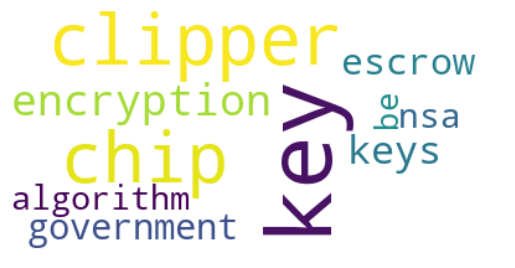

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def create_wordcloud(model, topic):
    text = {word: value for word, value in model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=1000)
    wc.generate_from_frequencies(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

# Show wordcloud
create_wordcloud(topic_model, topic=1)

## Finding similar topics between models

Whenever you have trained separate BERTopic models on different datasets, it might be worthful to find the similarities among these models. Is there overlap between topics in model A and topic in model B? In other words, can we find topics in model A that are similar to those in model B?

We can compare the topic representations of several models in two ways. First, by comparing the topic embeddings that are created when using the same embedding model across both fitted BERTopic instances. Second, we can compare the c-TF-IDF representations instead assuming we have fixed the vocabulary in both instances.

This example will go into the former, using the same embedding model across two BERTopic instances. To do this comparison, let's first create an example where I trained two models, one on an English dataset and one on a Dutch dataset:

In [26]:
from datasets import load_dataset
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP

# The same embedding model needs to be used for both topic models
# and since we are dealing with multiple languages, the model needs to be multi-lingual
sentence_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# To make this example reproducible
umap_model = UMAP(n_neighbors=15, n_components=5, 
                  min_dist=0.0, metric='cosine', random_state=42)

# English
en_dataset = load_dataset("stsb_multi_mt", name="en", split="train").to_pandas().sentence1.tolist()
en_model = BERTopic(embedding_model=sentence_model, umap_model=umap_model)
en_model.fit(en_dataset)

# Dutch
nl_dataset = load_dataset("stsb_multi_mt", name="nl", split="train").to_pandas().sentence1.tolist()
nl_model = BERTopic(embedding_model=sentence_model, umap_model=umap_model)
nl_model.fit(nl_dataset)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

test-00000-of-00001.parquet:   0%|          | 0.00/116k [00:00<?, ?B/s]

dev-00000-of-00001.parquet:   0%|          | 0.00/153k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/1500 [00:00<?, ? examples/s]

In the code above, there is one important thing to note and that is the sentence_model. This model needs to be exactly the same in all BERTopic models, otherwise, it is not possible to compare topic models.

Next, we can calculate the similarity between topics in the English topic model en_model and the Dutch model nl_model. To do so, we can simply calculate the cosine similarity between the topic_embedding of both models:

In [27]:
from sklearn.metrics.pairwise import cosine_similarity
sim_matrix = cosine_similarity(en_model.topic_embeddings_, nl_model.topic_embeddings_)

Now that we know which topics are similar to each other, we can extract the most similar topics. Let's say that we have topic 10 in the en_model which represents a topic related to trains:

In [28]:
topic = 10
en_model.get_topic(topic)

[('election', 0.13451501040427336),
 ('presidential', 0.11421781556508227),
 ('vote', 0.08297299843274003),
 ('egypt', 0.07386332343309536),
 ('constitution', 0.06654848604610775),
 ('elections', 0.06619419177995271),
 ('votes', 0.057998112472540816),
 ('egyptians', 0.05545707170508979),
 ('interim', 0.05368442739519704),
 ('maldives', 0.03775409572347966)]

To find the matching topic, we extract the most similar topic in the sim_matrix:

In [29]:
most_similar_topic = np.argmax(sim_matrix[topic + 1])-1
nl_model.get_topic(most_similar_topic)

[('grondwet', 0.16683763998892076),
 ('presidentsverkiezingen', 0.1514306909634394),
 ('egyptenaren', 0.13903136665743399),
 ('egypte', 0.11999811572182907),
 ('egyptische', 0.11426420846948937),
 ('stemt', 0.09705804838206883),
 ('stemmen', 0.09407249600357499),
 ('nieuwe', 0.058810025371636696),
 ('interim', 0.05561254666297359),
 ('presidentiële', 0.0522999354726029)]

It seems to be working as, for example, trein is a translation of train and sporen a translation of tracks! You can do this for every single topic to find out which topic in the en_model might belong to a model in the nl_model.

## Multimodal data
Concept is a variation of BERTopic for multimodal data, such as images with captions. Although we can use that package for multimodal data, we can perform a small trick with BERTopic to have a similar feature.

BERTopic is a relatively modular approach that attempts to isolate steps from one another. This means, for example, that you can use k-Means instead of HDBSCAN or PCA instead of UMAP as it does not make any assumptions with respect to the nature of the clustering.

Similarly, you can pass pre-calculated embeddings to BERTopic that represent the documents that you have. However, it does not make any assumption with respect to the relationship between those embeddings and the documents. This means that we could pass any metadata to BERTopic to cluster on instead of document embeddings. In this example, we can separate our embeddings from our documents so that the embeddings are generated from images instead of their corresponding images. Thus, we will cluster image embeddings but create the topic representation from the related captions.

In this example, we first need to fetch our data, namely the Flickr 8k dataset that contains images with captions:


In [30]:
import os
import glob
import zipfile
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
from sentence_transformers import SentenceTransformer, util

# Flickr 8k images
img_folder = 'photos/'
caps_folder = 'captions/'
if not os.path.exists(img_folder) or len(os.listdir(img_folder)) == 0:
    os.makedirs(img_folder, exist_ok=True)

    if not os.path.exists('Flickr8k_Dataset.zip'):   #Download dataset if does not exist
        util.http_get('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip', 'Flickr8k_Dataset.zip')
        util.http_get('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip', 'Flickr8k_text.zip')

    for folder, file in [(img_folder, 'Flickr8k_Dataset.zip'), (caps_folder, 'Flickr8k_text.zip')]:
        with zipfile.ZipFile(file, 'r') as zf:
            for member in tqdm(zf.infolist(), desc='Extracting'):
                zf.extract(member, folder)
images = list(glob.glob('photos/Flicker8k_Dataset/*.jpg'))

# Prepare dataframe
captions = pd.read_csv("captions/Flickr8k.lemma.token.txt",sep='\t',names=["img_id","img_caption"])
captions.img_id = captions.apply(lambda row: "photos/Flicker8k_Dataset/" + row.img_id.split(".jpg")[0] + ".jpg", 1)
captions = captions.groupby(["img_id"])["img_caption"].apply(','.join).reset_index()
captions = pd.merge(captions, pd.Series(images, name="img_id"), on="img_id")

# Extract images together with their documents/captions
images = captions.img_id.to_list()
docs = captions.img_caption.to_list()


  0%|          | 0.00/1.12G [00:00<?, ?B/s]

  0%|          | 0.00/2.34M [00:00<?, ?B/s]

Extracting: 100%|██████████| 10/10 [00:00<00:00, 578.87it/s]


Now that we have our images and captions, we need to generate our image embeddings:

In [31]:
model = SentenceTransformer('clip-ViT-B-32')

# Prepare images
batch_size = 32
nr_iterations = int(np.ceil(len(images) / batch_size))

# Embed images per batch
embeddings = []
for i in tqdm(range(nr_iterations)):
    start_index = i * batch_size
    end_index = (i * batch_size) + batch_size

    images_to_embed = [Image.open(filepath) for filepath in images[start_index:end_index]]
    img_emb = model.encode(images_to_embed, show_progress_bar=False)
    embeddings.extend(img_emb.tolist())

    # Close images
    for image in images_to_embed:
        image.close()
embeddings = np.array(embeddings)


modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

100%|██████████| 253/253 [01:15<00:00,  3.36it/s]


Finally, we can fit BERTopic the way we are used to, with documents and embeddings:

In [32]:
from bertopic import BERTopic
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(stop_words="english")
topic_model = BERTopic(vectorizer_model=vectorizer_model)
topics, probs = topic_model.fit_transform(docs, embeddings)
captions["Topic"] = topics

After fitting our model, let's inspect a topic about skateboarders:

In [33]:
topic_model.get_topic(2)

[('skateboard', 0.09019069462176811),
 ('skateboarder', 0.07620510854791479),
 ('trick', 0.07316506194279847),
 ('ramp', 0.055325815397764995),
 ('skate', 0.03707006063790341),
 ('perform', 0.03553672002262372),
 ('bicycle', 0.03458810827849276),
 ('bike', 0.03267795667389939),
 ('jump', 0.025080772645910385),
 ('air', 0.024356834954511054)]

Based on the above output, we can take an image to see if the representation makes sense:

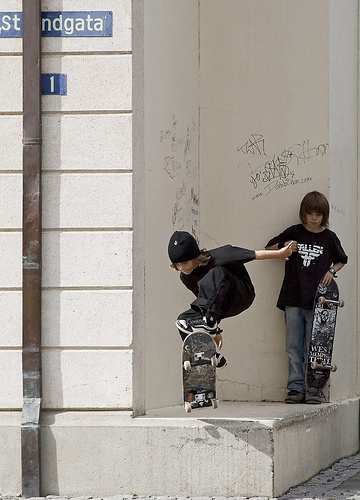

In [34]:
image = captions.loc[captions.Topic == 2, "img_id"].values.tolist()[0]
Image.open(image)
